Source course: https://cs231n.github.io/neural-networks-case-study/

# 1. Generate data

First we generate the spiral data with:
- $N = 100$ points per class
- $D = 2$ dimensions per point (two coordinates $(x_0, x_1)$)
- $K = 3$ number of classes (labels)

Therefore, there are $N \cdot K = 300$ data points total with $D = 2$ dimensions each. So `X.shape = (300, 2)` and `y.shape = (300,)`.

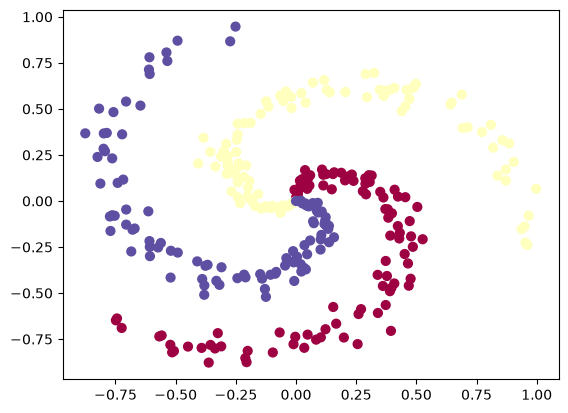

X.shape = (300, 2)
y.shape = (300,)


In [2]:
import numpy as np
from matplotlib import pyplot as plt

rng = np.random.default_rng()

N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype="uint8") # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + rng.standard_normal(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data:
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.show()

print(f"{X.shape = }")
print(f"{y.shape = }")

# 2. Training a linear classifier

## 2.1 Initialize parameters

**Notation.** To keep the indices readable we use **subscripts only**:

- a **superscript is always an exponent** (a power), never an index — e.g. $e^{s_{0,2}}$ is $e$ raised to the power $s_{0,2}$; the only exception is the parenthesized **layer tag** $w^{(1)}, w^{(2)}$ introduced in Section 3;
- the subscript order follows the matrix layout, **rows first, then columns**: $x_{i,d}$, $s_{i,k}$, $w_{d,k}$.
- inside a $\sum$, the **running index** must differ from any fixed index in the same expression: its primed twin is used ($d'$ over features, $j$ over classes, since $j$ is the running twin of $k$); when the role letter is not fixed in the expression it may run its own sum, e.g. $s_{i,k} = \sum_d x_{i,d} \, w_{d,k}$.

| Symbol | Meaning |
| --- | --- |
| $i$ | sample index, $0 \le i < N \cdot K$ (a row of $X$) |
| $d$ | feature/dimension index, $0 \le d < D$ (a column of $X$) |
| $k$ | class index, $0 \le k < K$ |
| $j$, $d'$ | running (bound) indices inside sums: $j$ over classes, $d'$ over features |
| $x_{i,d}$ | feature $d$ of sample $i$ |
| $y_i$ | correct class (label) of sample $i$ |
| $w_{d,k}$ | weight from feature $d$ to class $k$ |
| $b_k$ | bias of class $k$ |
| $s_{i,k}$ | score of class $k$ for sample $i$ |
| $s_{i,:}$ | the full score row of sample $i$ |
| $p_{i,k}$ | softmax probability of class $k$ for sample $i$ (defined in Section 2.2) |
| $L_i$ / $L$ | loss of sample $i$ / total loss |

The linear score function for one sample $i$ and one class $k$ is the weighted sum of the $D$ features of the sample with the weights of that class, plus the class bias:

$$
s_{i,k} = \sum_{d=0}^{D-1} x_{i,d} \, w_{d,k} + b_k .
$$

Stacking all samples as rows of $X$, the same expression for every sample and every class at once is the matrix product (all samples share the same weights and the same bias vector):

$$
S = X w + b, \qquad S_{i,k} = s_{i,k}.
$$

The dimensions of each component are:
- $X \in \mathbb{R}^{(N \cdot K) \times D}$
- $w \in \mathbb{R}^{D \times K}$
- $b \in \mathbb{R}^{K}$
- $S \in \mathbb{R}^{(N \cdot K) \times K}$

In [3]:
w = 0.01 * rng.standard_normal((D, K)) # same as depecrated np.random.randn
b = np.zeros(K)
scores = X @ w + b

print(f"{w.shape = }")
print(f"{b.shape = }")
print(f"{scores.shape = }")

w.shape = (2, 3)
b.shape = (3,)
scores.shape = (300, 3)


## 2.2 Calculate the loss

For this classifier we are using the softmax. Exponentiating the scores of a sample and normalizing them gives the **softmax probabilities**

$$
p_{i,k} = \frac{e^{s_{i,k}}}{\sum_j e^{s_{i,j}}},
$$

where the denominator sums $e^{s_{i,j}}$ over all classes $j$, so the probabilities of a sample are positive and sum to one ($\sum_k p_{i,k} = 1$). The loss of sample $i$ is then the negative log of the probability of its correct class $y_i$:

$$
L_i = -\log\left(\frac{e^{s_{i,y_i}}}{\sum_j e^{s_{i,j}}}\right) = -\log p_{i,y_i}.
$$

As simply explained in the course source:
> We can see that the Softmax classifier interprets every element of f as holding the (unnormalized) log probabilities of the three classes. We exponentiate these to get (unnormalized) probabilities, and then normalize them to get probabilites. Therefore, the expression inside the log is the normalized probability of the correct class. Note how this expression works: this quantity is always between 0 and 1. When the probability of the correct class is very small (near 0), the loss will go towards (positive) infinity. Conversely, when the correct class probability goes towards 1, the loss will go towards zero because $\log(1) = 0$. Hence, the expression for $L_i$ is low when the correct class probability is high, and it’s very high when it is low.

The full loss is the sum of the mean of all sample losses and the regularization loss with strength $\lambda$:

$$
L = \frac{1}{N \cdot K}\sum_i L_i + \frac{1}{2}\lambda\sum_d\sum_k w_{d,k}^2
$$

In [4]:
# e^{f_j} can produce really large numbers, which can provoke some numerical instability
# because floating point numbers have greater density around 0 (very small numbers)
# we could subract the maximum score to the rest of the scores (for each sample)
# to force the maximum value to be 0 so that max(e^f_j) = 1 (because e^0 = 1)
scores_adjusted = scores - scores.max(axis=1, keepdims=True) # max per sample (row), across classes
expscores = np.exp(scores_adjusted)
probs = expscores / expscores.sum(axis=1, keepdims=True)

reg = 0.1
data_loss = np.mean(-np.log(probs[np.arange(N*K), y])) # p_{i,y_i}
reg_loss = 0.5 * reg * np.sum(w**2)
loss = data_loss + reg_loss
expected_loss = -np.log(1/3) # expected loss random init -> uniform 1/3 prob for each class
diff = np.abs(loss - expected_loss)
print(f"loss: {loss:.6f}; expected: -ln 1/3 = {expected_loss:.6f}; diff: {diff:.6f}")

loss: 1.099384; expected: -ln 1/3 = 1.098612; diff: 0.000772


## 2.3 Compute the Analytic Gradient

In order to understand how the computed scores should change to decrease the loss $L_i$ that sample $i$ contributes to the full loss $L$, we calculate the gradient $\partial L_i / \partial s_{i,k}$, i.e. how the loss reacts when the score of one particular class $k$ changes (for a fixed sample $i$).

$$
\begin{align*}
    \frac{\partial L_i}{\partial s_{i,k}}
        &= \frac{\partial}{\partial s_{i,k}} \left[-\log \left(\frac{e^{s_{i,y_i}}}{\sum_j e^{s_{i,j}}}\right)\right]
         = -\frac{1}{e^{s_{i,y_i}} / \sum_j e^{s_{i,j}}} \frac{\partial}{\partial s_{i,k}} \left[\frac{e^{s_{i,y_i}}}{\sum_j e^{s_{i,j}}}\right] \\
        &= -\frac{\sum_j e^{s_{i,j}}}{e^{s_{i,y_i}}} \left( e^{s_{i,y_i}} \frac{\partial s_{i,y_i}}{\partial s_{i,k}} \frac{1}{\sum_j e^{s_{i,j}}}
             - \frac{e^{s_{i,y_i}}}{\left(\sum_j e^{s_{i,j}}\right)^2} \frac{\partial}{\partial s_{i,k}} \left[\sum_j e^{s_{i,j}}\right] \right) \\
        &= -\frac{\sum_j e^{s_{i,j}}}{e^{s_{i,y_i}}} \left( \frac{e^{s_{i,y_i}}}{\sum_j e^{s_{i,j}}} \frac{\partial s_{i,y_i}}{\partial s_{i,k}}
             - \frac{e^{s_{i,y_i}}}{\sum_j e^{s_{i,j}}} \left(\frac{1}{\sum_j e^{s_{i,j}}} \sum_j \frac{\partial e^{s_{i,j}}}{\partial s_{i,k}}\right) \right) \\
        &= -\frac{\sum_j e^{s_{i,j}}}{e^{s_{i,y_i}}} \left( \frac{e^{s_{i,y_i}}}{\sum_j e^{s_{i,j}}} \left(\mathbf{1}(y_i = k)
             - \frac{1}{\sum_j e^{s_{i,j}}} \sum_j\left[e^{s_{i,j}}\mathbf{1}(j = k)\right]\right) \right) \\
        &= -\frac{\sum_j e^{s_{i,j}}}{e^{s_{i,y_i}}} \left( \frac{e^{s_{i,y_i}}}{\sum_j e^{s_{i,j}}} \mathbf{1}(y_i = k)
             - \frac{e^{s_{i,k}} e^{s_{i,y_i}}}{\left(\sum_j e^{s_{i,j}}\right)^2} \right) \\
        &= -\frac{\sum_j e^{s_{i,j}}}{e^{s_{i,y_i}}} \left( \frac{e^{s_{i,y_i}} \sum_j e^{s_{i,j}}\mathbf{1}(y_i = k) - e^{s_{i,k}} e^{s_{i,y_i}}}{\left(\sum_j e^{s_{i,j}}\right)^2} \right) \\
        &= -\frac{\sum_j e^{s_{i,j}}\mathbf{1}(y_i = k) - e^{s_{i,k}}}{\sum_j e^{s_{i,j}}}
         = \frac{e^{s_{i,k}}}{\sum_j e^{s_{i,j}}} - \mathbf{1}(y_i = k)
\end{align*}
$$

Alternatively, by rewriting the loss, the derivative can be calculated much more easily:

$$
L_i = -\log\left(\frac{e^{s_{i,y_i}}}{\sum_j e^{s_{i,j}}}\right) = -s_{i,y_i} + \log\left(\sum_j e^{s_{i,j}}\right).
$$

Then,

$$
\begin{align*}
    \frac{\partial L_i}{\partial s_{i,k}}
        &= -\frac{\partial s_{i,y_i}}{\partial s_{i,k}}
         + \frac{\partial}{\partial s_{i,k}} \log\left(\sum_j e^{s_{i,j}}\right) \\
        &= -\mathbf{1}(y_i = k)
         + \frac{1}{\sum_j e^{s_{i,j}}} \frac{\partial}{\partial s_{i,k}} \left[\sum_j e^{s_{i,j}}\right] \\
        &= -\mathbf{1}(y_i = k)
         + \frac{1}{\sum_j e^{s_{i,j}}} \sum_j e^{s_{i,j}}\mathbf{1}(j = k) \\
        &= -\mathbf{1}(y_i = k)
         + \frac{e^{s_{i,k}}}{\sum_j e^{s_{i,j}}}.
\end{align*}
$$

Therefore, in terms of the softmax probabilities $p_{i,k}$ defined in Section 2.2:

$$
\boxed{
\frac{\partial L_i}{\partial s_{i,k}}
= \frac{e^{s_{i,k}}}{\sum_j e^{s_{i,j}}} - \mathbf{1}(y_i = k)
= p_{i,k} - \mathbf{1}(y_i = k)
}
$$

In words: **the gradient is the softmax probabilities minus a 1 at the correct class**.

$$
s_{i,k} = \sum_{d=0}^{D-1} x_{i,d} \, w_{d,k} + b_k
$$

Finally, to update the parameters, we are interested in $\partial L / \partial w_{d,k}$. By the chain rule through each score $s_{i,k}$ (where $\partial s_{i,k} / \partial w_{d,k} = x_{i,d}$), plus the gradient of the regularization term:

$$
\frac{\partial L}{\partial w_{d,k}}
    = \sum_i \frac{\partial L}{\partial s_{i,k}} \frac{\partial s_{i,k}}{\partial w_{d,k}} + \lambda w_{d,k}
    = \sum_i x_{i,d} \, \frac{p_{i,k} - \mathbf{1}(y_i = k)}{N \cdot K} + \lambda w_{d,k}
$$

Similarly,

$$
\frac{\partial L}{\partial b_k} = \sum_i \frac{p_{i,k} - \mathbf{1}(y_i = k)}{N \cdot K}
$$

The gradients of Section 2.3 tell us how the loss reacts to each score $s_{i,k}$, but to update the parameters we need $\partial L / \partial w_{d,k}$ and $\partial L / \partial b_k$. Since the scores are the only place where the parameters appear, we start from the score function again:

$$
s_{i,k} = \sum_{d=0}^{D-1} x_{i,d} \, w_{d,k} + b_k
$$

First, how a single score reacts to a change of a single weight. Differentiating the score function (with $d'$ as the running index inside the sum, because $d$ now denotes the fixed feature we differentiate with respect to — a summation index cannot reuse the same letter as a fixed index in the same expression, exactly like $j$ versus $k$ in the sums over classes):

$$
\begin{align*}
    \frac{\partial s_{i,k}}{\partial w_{d,k}}
        &= \frac{\partial}{\partial w_{d,k}} \left[\sum_{d'=0}^{D-1} x_{i,d'} \, w_{d',k} + b_k\right]
         = \sum_{d'=0}^{D-1} \frac{\partial}{\partial w_{d,k}} \left[x_{i,d'} \, w_{d',k}\right] + \frac{\partial b_k}{\partial w_{d,k}} \\
        &= \sum_{d'=0}^{D-1} x_{i,d'} \, \frac{\partial w_{d',k}}{\partial w_{d,k}} + 0
         = \sum_{d'=0}^{D-1} x_{i,d'} \, \mathbf{1}(d' = d)
         = x_{i,d},
\end{align*}
$$

because the features $x_{i,d'}$ and the bias $b_k$ do not depend on the weight $w_{d,k}$, and among the weights only $w_{d,k}$ itself depends on $w_{d,k}$ (the term with $d' = d$). The same reasoning for the bias gives

$$
\frac{\partial s_{i,k}}{\partial b_k}
    = \frac{\partial}{\partial b_k} \left[\sum_{d'=0}^{D-1} x_{i,d'} \, w_{d',k} + b_k\right]
    = 0 + 1 = 1,
$$

since only the bias term depends on $b_k$.

Then, by the chain rule, the weight $w_{d,k}$ influences the loss only through the class-$k$ scores, one per sample, so the contributions of all samples add up — together with the gradient of the regularization term:

$$
\begin{align*}
    \frac{\partial L}{\partial w_{d,k}}
        &= \sum_i \frac{\partial L}{\partial s_{i,k}} \frac{\partial s_{i,k}}{\partial w_{d,k}}
         + \frac{\partial}{\partial w_{d,k}} \left[\frac{1}{2}\lambda\sum_{d'}\sum_{k'} w_{d',k'}^2\right] \\
        &= \sum_i x_{i,d} \, \frac{p_{i,k} - \mathbf{1}(y_i = k)}{N \cdot K} + \lambda w_{d,k}.
\end{align*}
$$

Similarly, with $\partial s_{i,k} / \partial b_k = 1$:

$$
\frac{\partial L}{\partial b_k}
    = \sum_i \frac{\partial L}{\partial s_{i,k}} \frac{\partial s_{i,k}}{\partial b_k}
    = \sum_i \frac{p_{i,k} - \mathbf{1}(y_i = k)}{N \cdot K}.
$$

In summary:

$$
\boxed{
\frac{\partial L}{\partial w_{d,k}} = \sum_i x_{i,d} \, \frac{p_{i,k} - \mathbf{1}(y_i = k)}{N \cdot K} + \lambda w_{d,k},
\qquad
\frac{\partial L}{\partial b_k} = \sum_i \frac{p_{i,k} - \mathbf{1}(y_i = k)}{N \cdot K}
}
$$

In [5]:
dscores = probs.copy()
dscores[np.arange(N*K), y] -= 1 # entry [i, y_i]: subtract 1 only at each sample's correct class
dscores /= N*K

dw = X.T @ dscores
dw += reg*w
db = dscores.sum(axis=0) # sum along all examples because they contribute equally

Now that we have the gradient for each parameter we can perform a single update in the negative gradient direction to decrease the loss:

In [6]:
step_size = 0.1
w += -step_size * dw
b += -step_size * db

## 2.4 Training loop

training accuracy: 0.493333


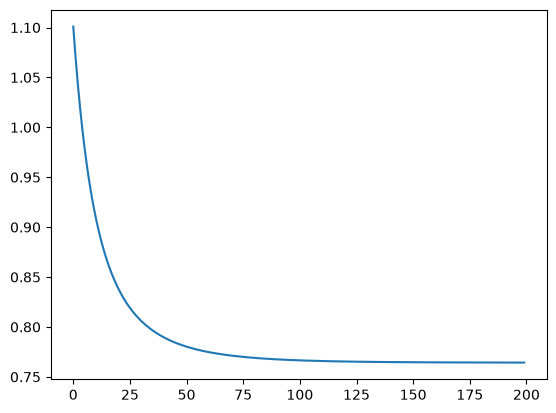

In [7]:
w = 0.01 * rng.standard_normal((D, K)) # same as depecrated np.random.randn
b = np.zeros(K)

step_size = 1e-0
reg = 1e-3

n_iter = 200
losses = np.zeros(n_iter)
sample_idx = np.arange(N*K) # pairwise index [i, y_i]

for i in range(n_iter):
    scores = X @ w + b

    # calculate scores and probabilities
    scores_adjusted = scores - scores.max(axis=1, keepdims=True) # max per sample (row), across classes
    expscores = np.exp(scores_adjusted)
    probs = expscores / expscores.sum(axis=1, keepdims=True)

    # calculate the loss
    data_loss = np.mean(-np.log(probs[sample_idx, y])) # p_{i,y_i}
    reg_loss = 0.5 * reg * np.sum(w**2)
    loss = data_loss + reg_loss

    # calculate the gradient for scores
    dscores = probs.copy()
    dscores[sample_idx, y] -= 1 # subtract 1 only at each sample's correct class
    dscores /= N*K

    # backpropagate the gradient to parameters
    dw = X.T @ dscores
    dw += reg * w
    db = dscores.sum(axis=0)

    # perform a single parameter update 
    w += -step_size * dw
    b += -step_size * db

    losses[i] = loss
    # if i % 50 == 0: print(f"iteration {i}; loss: {loss:.6f}")

plt.plot(np.arange(n_iter), losses)

scores = np.dot(X, w) + b
predicted_class = np.argmax(scores, axis=1)
print(f"training accuracy: {np.mean(predicted_class == y):.6f}")

## 2.5 Visualize the decision boundaries

The predicted class of a point is $\arg\max_k s_k$, so the boundary between two classes $k$ and $k'$ is the set of points where their scores are equal,


$$
\begin{align*}
    s_{i,k} - s_{i,k'}
        &= \left(\sum_d x_{i,d} \, w_{d,k} + b_k\right) - \left(\sum_d x_{i,d} \, w_{d,k'} + b_{k'}\right) \\
        &= \sum_d \left[ x_{i,d} \, w_{d,k} - x_{i,d} \, w_{d,k'}\right] + (b_{k} - b_{k'}) \\
        &= \sum_d x_{i,d} \, (w_{d,k} - w_{d,k'}) + (b_k - b_{k'}) = 0
\end{align*}
$$

which for a linear classifier is a straight line in the $(x_0, x_1)$ plane. To visualize the regions, evaluate the trained model on a dense grid of the plane and color each grid point by its predicted class (uses the `w`, `b` trained in Section 2.4):

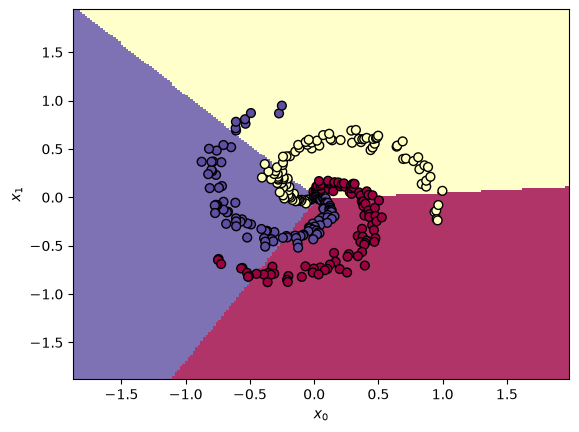

In [11]:
def plot_separation(fn):
    # evaluate the model on a dense grid of the (x0, x1) plane
    h = 0.02 # grid step
    x0_min, x0_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x1_min, x1_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x0_min, x0_max, h), np.arange(x1_min, x1_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()] # each grid point as a sample

    # scores_grid = grid @ w + b
    scores_grid = fn(grid)
    Z = np.argmax(scores_grid, axis=1).reshape(xx.shape) # predicted class of each grid point

    plt.pcolormesh(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8, shading="auto")
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral, edgecolors="k")
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xlabel("$x_0$")
    plt.ylabel("$x_1$")
    plt.show()

plot_separation(lambda x: x @ w + b)

# 3. Training a Neural Network

With a two layer neural network we have to introduce a non-linearity in between them (otherwise the composition of two linear maps would collapse into a single linear map). In this case we are going to use ReLU: $\max(0, x)$.

To distinguish the parameters of each layer we tag them with a **parenthesized layer number**: $w^{(1)}, b^{(1)}$ for the first layer and $w^{(2)}, b^{(2)}$ for the second — the one allowed use of a superscript besides exponents. The hidden layer has $H$ units (code: `h`), indexed by $g$, $0 \le g < H$. The forward pass is

$$
z_{i,g} = \sum_{d=0}^{D-1} x_{i,d} \, w^{(1)}_{d,g} + b^{(1)}_g, \qquad
h_{i,g} = \max(0, z_{i,g}), \qquad
s_{i,k} = \sum_{g=0}^{H-1} h_{i,g} \, w^{(2)}_{g,k} + b^{(2)}_k,
$$

where $z$ is the pre-activation, $h$ the post-ReLU hidden activation (code: `lh`) and $s$ the scores as before. In matrix form: $h = \max(0, X w^{(1)} + b^{(1)})$ and $S = h \, w^{(2)} + b^{(2)}$.

Just like in the linear classifier, the probabilities and the loss are computed in the same way from the scores (each layer is now regularized, and note that the index ranges of the two weight matrices differ):

$$
p_{i,k} = \frac{e^{s_{i,k}}}{\sum_j e^{s_{i,j}}}, \qquad
L = \frac{1}{N \cdot K}\sum_i -\log p_{i,y_i} + \frac{1}{2}\lambda\sum_d\sum_g (w^{(1)}_{d,g})^2 + \frac{1}{2}\lambda\sum_g\sum_k (w^{(2)}_{g,k})^2 .
$$

**Backpropagation.** Since the loss is the same function of the scores as before, the score gradient is unchanged:

$$
\frac{\partial L}{\partial s_{i,k}} = \frac{p_{i,k} - \mathbf{1}(y_i = k)}{N \cdot K}.
$$

The second layer is a linear classifier exactly like the one in Section 2, only with the hidden activations $h_{i,g}$ playing the role of the features $x_{i,d}$:

$$
\frac{\partial L}{\partial w^{(2)}_{g,k}} = \sum_i h_{i,g} \, \frac{p_{i,k} - \mathbf{1}(y_i = k)}{N \cdot K} + \lambda w^{(2)}_{g,k},
\qquad
\frac{\partial L}{\partial b^{(2)}_k} = \sum_i \frac{p_{i,k} - \mathbf{1}(y_i = k)}{N \cdot K}.
$$

For the first layer we first chain the gradient back through the second layer into the hidden activations (each $h_{i,g}$ influences every class score $s_{i,k}$ of sample $i$):

$$
\frac{\partial L}{\partial h_{i,g}} = \sum_k \frac{\partial L}{\partial s_{i,k}} \, w^{(2)}_{g,k},
$$

and then through the ReLU non-linearity, whose derivative is

$$
\frac{\partial h_{i,g}}{\partial z_{i,g}} = \begin{cases}
0, & z_{i,g} \le 0 \\
1, & z_{i,g} > 0
\end{cases}
$$

(technically $\max$ has a kink at $z = 0$ — it is continuous there but not differentiable — so by convention we assign it a gradient of 0). Hence

$$
\frac{\partial L}{\partial z_{i,g}} = \frac{\partial L}{\partial h_{i,g}} \, \mathbf{1}(z_{i,g} > 0).
$$

**TLDR:** the gradient of the ReLU non-linearity acts as a masking operation: the gradients of hidden units whose pre-activation was $\le 0$ get squashed to 0.

Finally, the first layer is again a linear classifier (with $z$ in place of the scores), applied to the masked gradient:

$$
\frac{\partial L}{\partial w^{(1)}_{d,g}} = \sum_i x_{i,d} \, \frac{\partial L}{\partial z_{i,g}} + \lambda w^{(1)}_{d,g},
\qquad
\frac{\partial L}{\partial b^{(1)}_g} = \sum_i \frac{\partial L}{\partial z_{i,g}} .
$$

training accuracy: 0.993333


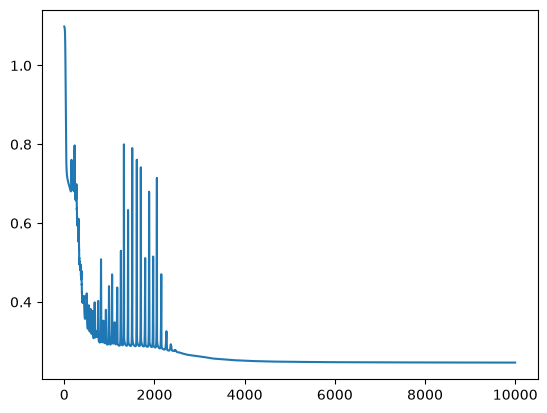

In [9]:
h = 100 # hidden layer size

w1 = 0.01 * rng.standard_normal((D, h))
b1 = np.zeros(h)
w2 = 0.01 * rng.standard_normal((h, K))
b2 = np.zeros(K)

step_size = 1e-0
reg = 1e-3
n_iter = 10000
losses = np.zeros(n_iter)
sample_idx = np.arange(N*K)

for i in range(n_iter):
    lh = np.maximum(0, X @ w1 + b1) # ReLu
    scores = lh @ w2 + b2

    # calculate scores and probabilities
    scores_adjusted = scores - scores.max(axis=1, keepdims=True) # max per sample (row), across classes
    expscores = np.exp(scores_adjusted)
    probs = expscores / expscores.sum(axis=1, keepdims=True)

    # calculate the loss
    data_loss = np.mean(-np.log(probs[sample_idx, y])) # p_{i,y_i}
    reg_loss = 0.5 * reg * np.sum(w1**2) + 0.5 * reg * np.sum(w2**2)
    loss = data_loss + reg_loss

    # calculate the gradient for scores
    dscores = probs.copy()
    dscores[sample_idx, y] -= 1 # subtract 1 only at each sample's correct class
    dscores /= N*K

    # backpropagate the gradient to layer 2
    dw2 = lh.T @ dscores
    dw2 += reg * w2
    db2 = dscores.sum(axis=0)

    # backpropagate the gradient to the hidden layer
    dh = dscores @ w2.T
    dh[lh <= 0] = 0

    # backpropagate the gradient to layer 1
    dw1 = X.T @ dh
    dw1 += reg * w1
    db1 = dh.sum(axis=0)

    # perform a single parameter update
    w1 += -step_size * dw1
    b1 += -step_size * db1
    w2 += -step_size * dw2
    b2 += -step_size * db2

    losses[i] = loss

plt.plot(np.arange(n_iter), losses)

scores = np.maximum(0, X @ w1 + b1) @ w2 + b2
predicted_class = np.argmax(scores, axis=1)
print(f"training accuracy: {np.mean(predicted_class == y):.6f}")

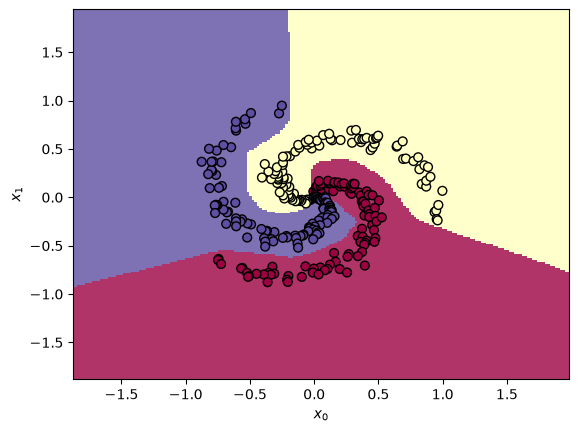

In [12]:
plot_separation(lambda x: np.maximum(0, x @ w1 + b1) @ w2 + b2)